In [6]:
import requests
import json

In [7]:
lat=23.033863
lon=72.585022
key="a98092485f73a68402f2760d1c1269df"
url=f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={key}"
data=requests.get(url)
data.status_code

final=data.json()


new=json.dumps(final,indent=5)

print(new)

{
     "coord": {
          "lon": 72.5873,
          "lat": 23.0258
     },
     "weather": [
          {
               "id": 800,
               "main": "Clear",
               "description": "clear sky",
               "icon": "01d"
          }
     ],
     "base": "stations",
     "main": {
          "temp": 314.16,
          "feels_like": 312.98,
          "temp_min": 314.16,
          "temp_max": 314.16,
          "pressure": 1003,
          "humidity": 17,
          "sea_level": 1003,
          "grnd_level": 998
     },
     "visibility": 6000,
     "wind": {
          "speed": 6.17,
          "deg": 200
     },
     "clouds": {
          "all": 0
     },
     "dt": 1779707964,
     "sys": {
          "type": 1,
          "id": 9049,
          "country": "IN",
          "sunrise": 1779668726,
          "sunset": 1779716880
     },
     "timezone": 19800,
     "id": 1279233,
     "name": "Ahmedabad",
     "cod": 200
}


In [8]:
import pandas as pd

In [9]:
df=pd.DataFrame({
    "lon": [final["coord"]["lon"]],
    "lat":[final["coord"]["lat"]],
    "city": [final["name"]],
    "id": [final["id"]]
})

In [10]:
df

,lon,lat,city,id
0,72.5873,23.0258,Ahmedabad,1279233


In [15]:
lat=23.033863
lon=72.585022
key="a98092485f73a68402f2760d1c1269df"
url=f"https://api.openweathermap.org/data/2.5/forecast?lat={lat}&lon={lon}&appid={key}"
data=requests.get(url)
data.status_code

final=data.json()


new=json.dumps(final,indent=5)

print(new)

{
     "cod": "200",
     "message": 0,
     "cnt": 40,
     "list": [
          {
               "dt": 1779710400,
               "main": {
                    "temp": 314.18,
                    "feels_like": 313.01,
                    "temp_min": 314.18,
                    "temp_max": 315.56,
                    "pressure": 1003,
                    "sea_level": 1003,
                    "grnd_level": 997,
                    "humidity": 17,
                    "temp_kf": -1.38
               },
               "weather": [
                    {
                         "id": 800,
                         "main": "Clear",
                         "description": "clear sky",
                         "icon": "01d"
                    }
               ],
               "clouds": {
                    "all": 0
               },
               "wind": {
                    "speed": 6.4,
                    "deg": 275,
                    "gust": 6.42
               },
               "vi

In [16]:
date=[]
time=[]
temp_k=[]
temp_d=[]
temp_f=[]
for i in final["list"]:
    d=i["dt_txt"]
    date.append(d.split(" ")[0])
    time.append(d.split(" ")[1])
    temp_k.append(i["main"]["temp"])
    temp_d.append((i["main"]["temp"]-273.15))
    temp_f.append((i["main"]["temp"])*(9/5)+32)
df=pd.DataFrame({"date":date,"time":time,"temp_k":temp_k,"temp_d":temp_d,"temp_f":temp_f})
df

,date,time,temp_k,temp_d,temp_f
0,2026-05-25,12:00:00,314.18,41.03,597.524
1,2026-05-25,15:00:00,312.73,39.58,594.914
2,2026-05-25,18:00:00,308.39,35.24,587.102
3,2026-05-25,21:00:00,303.04,29.89,577.472
4,2026-05-26,00:00:00,301.49,28.34,574.682
5,2026-05-26,03:00:00,304.79,31.64,580.622
6,2026-05-26,06:00:00,311.99,38.84,593.582
7,2026-05-26,09:00:00,316.37,43.22,601.466
8,2026-05-26,12:00:00,315.77,42.62,600.386
9,2026-05-26,15:00:00,309.55,36.40,589.190


In [17]:
import matplotlib.pyplot as plt

<BarContainer object of 5 artists>

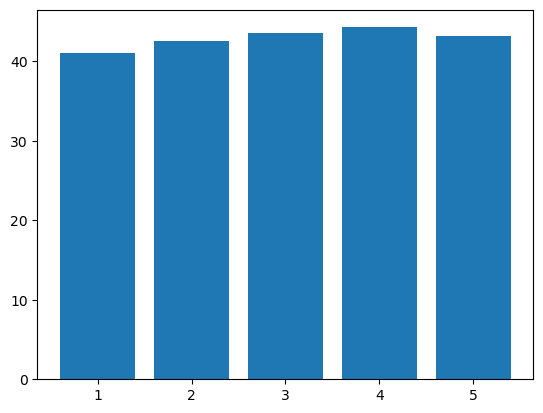

In [18]:
plt.bar([1,2,3,4,5],df[df["time"]=="12:00:00"]["temp_d"])

In [19]:
plt.bar??

Signature:
plt.bar(
    x: 'float | ArrayLike',
    height: 'float | ArrayLike',
    width: 'float | ArrayLike' = 0.8,
    bottom: 'float | ArrayLike | None' = None,
    *,
    align: "Literal['center', 'edge']" = 'center',
    data=None,
    **kwargs,
) -> 'BarContainer'
Docstring:
Make a bar plot.

The bars are positioned at *x* with the given *align*\ment. Their
dimensions are given by *height* and *width*. The vertical baseline
is *bottom* (default 0).

Many parameters can take either a single value applying to all bars
or a sequence of values, one for each bar.

Parameters
----------
x : float or array-like
    The x coordinates of the bars. See also *align* for the
    alignment of the bars to the coordinates.

height : float or array-like
    The height(s) of the bars.

    Note that if *bottom* has units (e.g. datetime), *height* should be in
    units that are a difference from the value of *bottom* (e.g. timedelta).

width : float or array-like, default: 0.8
    The width(s) 